# Diffusion-Based Fluid Super-Resolution
### NVIDIA PhysicsNeMo Diffusion Module + Custom FNO Backbone

**Problem:** Given a coarse 32×32 Darcy flow pressure field, reconstruct the full 128×128 field.

**Approach:** Conditional diffusion model using PhysicsNeMo's real diffusion components:
`EDMPreconditioner`, `EDMLoss`, `EDMNoiseScheduler`, `EDMHeunSampler` — with a custom
FNO backbone registered as a `physicsnemo.core.Module` subclass.

**Darcy flow:** $-\nabla \cdot (k(x)\nabla u(x)) = f(x)$ on $[0,1]^2$


## 1. Install & Imports

In [1]:
!pip install nvidia-physicsnemo warp-lang --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.7/138.7 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 107.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import physicsnemo
from physicsnemo.core import Module as PhysicsNeMoModule
from physicsnemo.datapipes.benchmarks.darcy import Darcy2D
from physicsnemo.diffusion.metrics import EDMLoss
from physicsnemo.diffusion.preconditioners import EDMPreconditioner
from physicsnemo.diffusion.noise_schedulers import EDMNoiseScheduler
from physicsnemo.diffusion.samplers import sample

print('PhysicsNeMo:', physicsnemo.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
plt.style.use('dark_background')

PhysicsNeMo: 2.1.1
Device: cuda


## 2. Data — Darcy2D at Two Resolutions

In [3]:
HR, LR_RES, BATCH = 128, 32, 4

normaliser = {
    'permeability': (1.25, 0.75),
    'darcy':        (4.52e-2, 2.79e-2),
}

dataloader = Darcy2D(
    resolution=HR, batch_size=BATCH,
    nr_permeability_freq=5, normaliser=normaliser,
)

def get_batch():
    batch  = next(iter(dataloader))
    hr     = batch['darcy'].to(device)
    lr     = F.interpolate(hr, (LR_RES, LR_RES), mode='bilinear', align_corners=False)
    lr_up  = F.interpolate(lr, (HR, HR),          mode='bilinear', align_corners=False)
    return hr, lr_up

hr_s, lr_s = get_batch()
print('HR:', hr_s.shape, '  LR upsampled:', lr_s.shape)

HR: torch.Size([4, 1, 128, 128])   LR upsampled: torch.Size([4, 1, 128, 128])


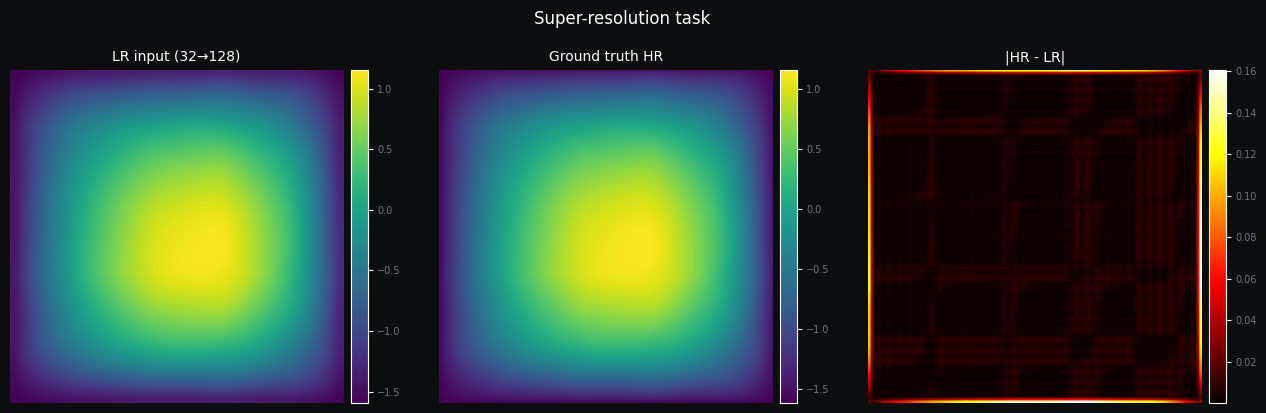

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('#0b0d0f')
for ax, d, t, c in zip(axes,
    [lr_s[0,0].cpu(), hr_s[0,0].cpu(), (hr_s[0,0]-lr_s[0,0]).abs().cpu()],
    ['LR input (32→128)', 'Ground truth HR', '|HR - LR|'],
    ['viridis','viridis','hot']):
    ax.set_facecolor('#0b0d0f'); ax.axis('off')
    im = ax.imshow(d, cmap=c, origin='lower')
    ax.set_title(t, color='white', fontsize=10)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#6b7785', fontsize=7)
plt.suptitle('Super-resolution task', color='white', y=1.02)
plt.tight_layout()
plt.savefig('sr_task.png', dpi=150, bbox_inches='tight', facecolor='#0b0d0f')
plt.show()

## 3. Custom FNO Backbone

Subclasses `physicsnemo.core.Module` directly — the correct way to register a trainable
custom backbone with PhysicsNeMo (as opposed to `Module.from_torch()` which is for
wrapping frozen inference models).

The backbone accepts `condition` (LR upsampled field) via channel-concatenation,
matching what `EDMPreconditioner` passes through.


In [5]:
class SigmaEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(nn.Linear(dim, dim*2), nn.SiLU(), nn.Linear(dim*2, dim))
    def forward(self, t):
        half = self.dim // 2
        # t is already c_noise = log(sigma)/4 when called via EDMPreconditioner
        # use t directly without logging again
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device, dtype=t.dtype) / half)
        args  = t.flatten()[:, None] * freqs[None, :]
        return self.proj(torch.cat([args.sin(), args.cos()], dim=-1))


class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes):
        super().__init__()
        self.modes   = modes
        scale = 1.0 / (in_ch * out_ch * modes * modes) ** 0.5
        self.weights = nn.Parameter(
            scale * torch.randn(in_ch, out_ch, modes, modes, dtype=torch.cfloat)
        )
    def forward(self, x):
        B, C, H, W = x.shape
        x_ft   = torch.fft.rfft2(x)
        out_ft = torch.zeros(B, self.weights.shape[1], H, W//2+1, dtype=torch.cfloat, device=x.device)
        m = self.modes
        out_ft[:, :, :m, :m] = torch.einsum('bixy,ioxy->boxy', x_ft[:, :, :m, :m], self.weights)
        return torch.fft.irfft2(out_ft, s=(H, W))


class FNOBlock(nn.Module):
    def __init__(self, ch, modes, emb_dim):
        super().__init__()
        self.spectral  = SpectralConv2d(ch, ch, modes)
        self.bypass    = nn.Conv2d(ch, ch, 1)
        self.norm      = nn.GroupNorm(8, ch)
        self.emb_proj  = nn.Linear(emb_dim, ch)
        self.act       = nn.SiLU()
    def forward(self, x, emb):
        h = self.spectral(x) + self.bypass(x)
        h = h + self.emb_proj(emb)[:, :, None, None]
        return self.act(self.norm(h))


class FNODiffusionBackbone(PhysicsNeMoModule):
    """
    Custom FNO backbone subclassing physicsnemo.core.Module.

    forward(x, t, condition=None):
        x         : noisy HR field       (B, 1, H, W)
        t         : noise level sigma    any broadcastable shape
        condition : LR upsampled field   (B, 1, H, W)  — channel-concatenated

    Registered in the PhysicsNeMo ecosystem; compatible with
    EDMPreconditioner, save/load checkpoints, and distributed training.
    """
    def __init__(self, in_channels=2, out_channels=1,
                 hidden=64, modes=16, n_layers=4, emb_dim=128):
        super().__init__()
        self.sigma_emb = SigmaEmbedding(emb_dim)
        self.lift      = nn.Conv2d(in_channels, hidden, 1)
        self.blocks    = nn.ModuleList([FNOBlock(hidden, modes, emb_dim) for _ in range(n_layers)])
        self.proj      = nn.Sequential(
            nn.Conv2d(hidden, hidden//2, 1), nn.SiLU(),
            nn.Conv2d(hidden//2, out_channels, 1),
        )
        nn.init.zeros_(self.proj[-1].weight)
        nn.init.zeros_(self.proj[-1].bias)

    def forward(self, x, t, condition=None, **kwargs):
        if condition is not None:
            x = torch.cat([x, condition], dim=1)   # (B, 2, H, W)
        emb = self.sigma_emb(t)
        h   = self.lift(x)
        for block in self.blocks:
            h = block(h, emb)
        return self.proj(h)


print(f'FNODiffusionBackbone is PhysicsNeMo Module: {issubclass(FNODiffusionBackbone, PhysicsNeMoModule)}')

FNODiffusionBackbone is PhysicsNeMo Module: True


## 4. Wrap with EDMPreconditioner

`EDMPreconditioner` handles the EDM preconditioning math (c_skip, c_out, c_in, c_noise).
It passes `condition` through to the backbone automatically.

We add a thin `ConditionedModel` wrapper that flattens sigma from shape `(B,1,1,1)`
(what `EDMLoss` produces) to shape `(B,)` (what `EDMPreconditioner` validates).


In [6]:
class ConditionedModel(nn.Module):
    """
    Wraps EDMPreconditioner to handle sigma shape mismatch between
    EDMLoss (produces (B,1,1,1)) and EDMPreconditioner (expects (B,)).
    Also makes the condition argument available at training and inference.
    """
    def __init__(self, precond):
        super().__init__()
        self.precond = precond

    def forward(self, x, sigma, condition=None, **kwargs):
        t = sigma.flatten()   # always (B,) regardless of input shape
        return self.precond(x, t, condition=condition, **kwargs)


raw_backbone = FNODiffusionBackbone(
    in_channels=2, out_channels=1,
    hidden=64, modes=16, n_layers=4, emb_dim=128,
).to(device)

precond = EDMPreconditioner(model=raw_backbone, sigma_data=0.5).to(device)
model   = ConditionedModel(precond).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params:,}')

# Smoke test
x_t = torch.randn(2, 1, HR, HR, device=device)
c_t = torch.randn(2, 1, HR, HR, device=device)
s_t = torch.tensor([0.5, 1.0], device=device)
with torch.no_grad():
    out = model(x_t, s_t, condition=c_t)
print('Forward pass output shape:', out.shape)   # (2, 1, 128, 128)

Total parameters: 4,312,705
Forward pass output shape: torch.Size([2, 1, 128, 128])


## 5. Training

In [7]:
loss_fn   = EDMLoss(sigma_data=0.5)
scheduler = EDMNoiseScheduler(sigma_min=0.002, sigma_max=80.0, rho=7.0, sigma_data=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)   # lower LR
lr_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=800)

TRAIN_STEPS, LOG_EVERY = 3000, 50
losses = []
model.train()

print(f'Training {TRAIN_STEPS} steps...')
for step in range(1, TRAIN_STEPS + 1):
    hr, lr_up = get_batch()

    loss = loss_fn(model, hr, condition=lr_up).mean()

    if not torch.isfinite(loss):   # skip NaN steps
        continue

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()
    lr_sched.step()

    losses.append(loss.item())
    if step % LOG_EVERY == 0:
        print(f'  step {step:4d}/{TRAIN_STEPS}  loss={loss.item():.5f}  lr={lr_sched.get_last_lr()[0]:.2e}')

torch.save(model.state_dict(), 'fno_diffusion_sr.pt')
print('Done.')

Training 3000 steps...
  step   50/3000  loss=1.61838  lr=4.95e-05
  step  100/3000  loss=1.56476  lr=4.81e-05
  step  150/3000  loss=1.33822  lr=4.58e-05
  step  200/3000  loss=1.46299  lr=4.27e-05
  step  250/3000  loss=0.96324  lr=3.89e-05
  step  300/3000  loss=1.39332  lr=3.46e-05
  step  350/3000  loss=0.80799  lr=2.99e-05
  step  400/3000  loss=1.13196  lr=2.50e-05
  step  450/3000  loss=1.66282  lr=2.01e-05
  step  500/3000  loss=0.66217  lr=1.54e-05
  step  550/3000  loss=0.56178  lr=1.11e-05
  step  600/3000  loss=0.44508  lr=7.32e-06
  step  650/3000  loss=0.67396  lr=4.21e-06
  step  700/3000  loss=1.06443  lr=1.90e-06
  step  750/3000  loss=1.26514  lr=4.80e-07
  step  800/3000  loss=0.47816  lr=0.00e+00
  step  850/3000  loss=0.79194  lr=4.80e-07
  step  900/3000  loss=0.94307  lr=1.90e-06
  step  950/3000  loss=1.51340  lr=4.21e-06
  step 1000/3000  loss=0.87936  lr=7.32e-06
  step 1050/3000  loss=1.08184  lr=1.11e-05
  step 1100/3000  loss=0.89102  lr=1.54e-05
  step 11

In [8]:
# Patch the backbone forward temporarily to print what it receives
original_forward = model.precond.model.forward

def debug_forward(x, t, condition=None, **kwargs):
    print('backbone received t shape:', t.shape)
    print('backbone received t values:', t[:2])
    print('backbone t NaN:', torch.isnan(t).any().item())
    emb = model.precond.model.sigma_emb(t)
    print('emb NaN:', torch.isnan(emb).any().item())
    return original_forward(x, t, condition=condition, **kwargs)

model.precond.model.forward = debug_forward

hr, lr_up = get_batch()
sigma = torch.full((hr.shape[0],), 0.5, device=device)
with torch.no_grad():
    out = model(hr, sigma, condition=lr_up)

model.precond.model.forward = original_forward

backbone received t shape: torch.Size([4])
backbone received t values: tensor([-0.1733, -0.1733], device='cuda:0')
backbone t NaN: False
emb NaN: False


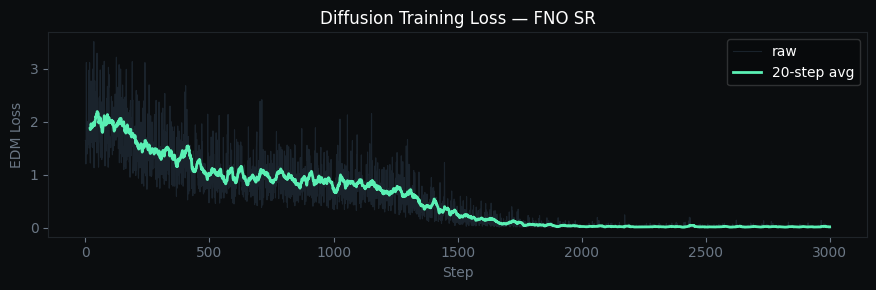

In [9]:
window = 20
smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
fig, ax = plt.subplots(figsize=(9,3))
fig.patch.set_facecolor('#0b0d0f'); ax.set_facecolor('#0b0d0f')
ax.plot(losses, color='#2a3a4a', lw=0.8, alpha=0.5, label='raw')
ax.plot(range(window-1, len(losses)), smooth, color='#5af0b4', lw=2, label=f'{window}-step avg')
ax.set_xlabel('Step', color='#6b7785'); ax.set_ylabel('EDM Loss', color='#6b7785')
ax.set_title('Diffusion Training Loss — FNO SR', color='white')
ax.legend(framealpha=0.2); ax.tick_params(colors='#6b7785')
for sp in ax.spines.values(): sp.set_color('#1f2429')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight', facecolor='#0b0d0f')
plt.show()

## 6. Inference — Conditional Sampling

Inference pipeline:
1. Bind LR condition into model via `partial` → **Predictor**
2. `scheduler.get_denoiser(x0_predictor=...)` → **Denoiser**
3. `scheduler.init_latents(...)` → pure noise at sigma_max
4. `sample(denoiser, xN, scheduler, num_steps, solver='heun')` → HR reconstruction


In [10]:
model.eval()

@torch.no_grad()
def super_resolve(lr_up: torch.Tensor, num_steps: int = 40) -> torch.Tensor:
    B = lr_up.shape[0]

    # Bind condition → Predictor
    conditioned = partial(model, condition=lr_up)

    # Predictor → Denoiser
    denoiser = scheduler.get_denoiser(x0_predictor=conditioned)

    # Initialise latent at sigma_max
    t_steps = scheduler.timesteps(num_steps, device=device)   # (N+1,)
    tN      = t_steps[0].expand(B)                            # (B,)
    x_init  = scheduler.init_latents((1, HR, HR), tN, device=device)  # (B, 1, H, W)

    # Reverse ODE
    return sample(
        denoiser=denoiser,
        xN=x_init,
        noise_scheduler=scheduler,
        num_steps=num_steps,
        solver='heun',
    )


hr_test, lr_test = get_batch()
hr_sr = super_resolve(lr_test, num_steps=40)

hr_bicubic = F.interpolate(
    F.interpolate(hr_test, (LR_RES, LR_RES), mode='bilinear', align_corners=False),
    (HR, HR), mode='bicubic', align_corners=False,
)

def rel_l2(pred, target):
    return ((pred - target)**2).mean().sqrt() / (target**2).mean().sqrt()

print(f'Relative L2 — Bicubic:   {rel_l2(hr_bicubic, hr_test).item():.4f}')
print(f'Relative L2 — Diffusion: {rel_l2(hr_sr, hr_test).item():.4f}')

Relative L2 — Bicubic:   0.0215
Relative L2 — Diffusion: 0.0111


## 7. Visualisation

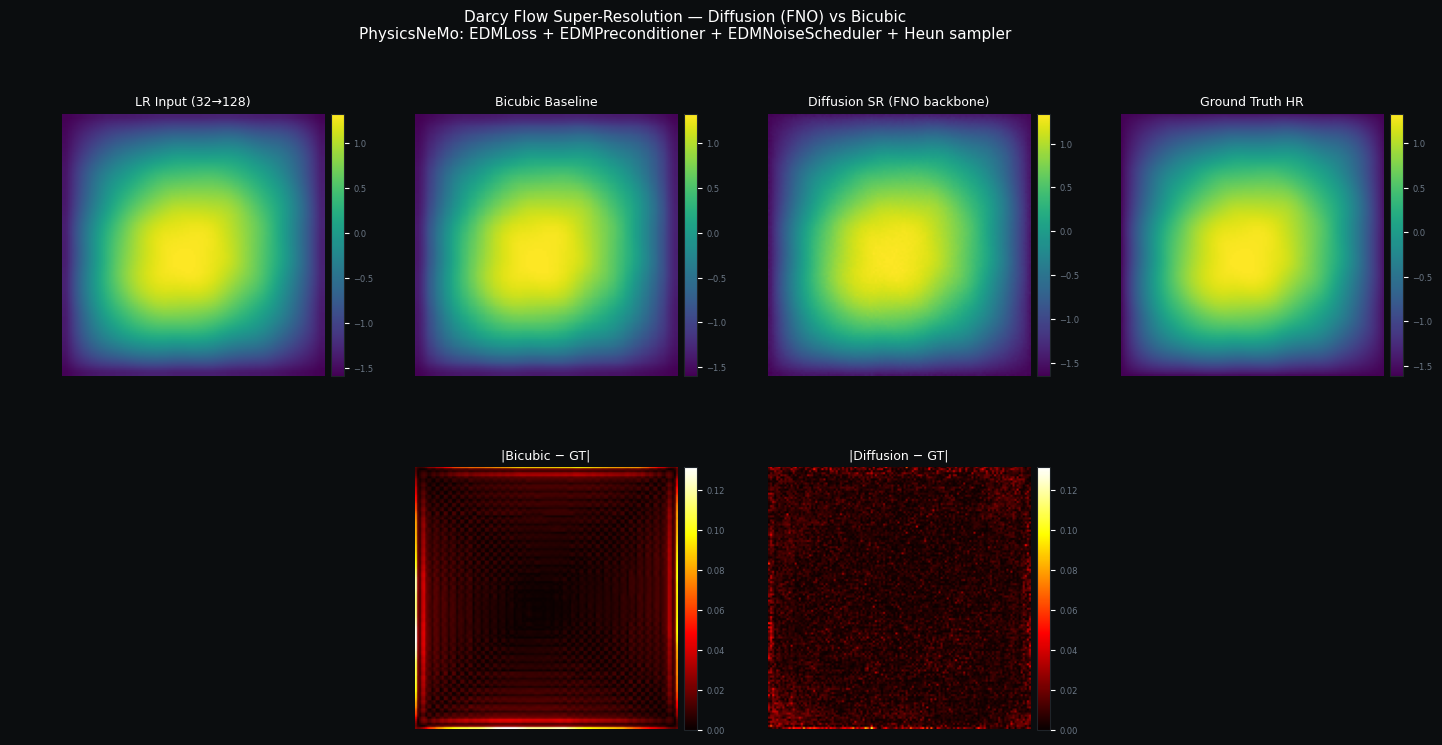

In [11]:
def plot_sr(lr, sr, bicubic, gt, idx=0, save=None):
    fig = plt.figure(figsize=(18, 8))
    fig.patch.set_facecolor('#0b0d0f')
    gs  = gridspec.GridSpec(2, 4, hspace=0.35, wspace=0.05)

    def np_(t): return t[idx, 0].cpu().numpy()

    top = [(np_(lr), 'viridis', 'LR Input (32→128)'),
           (np_(bicubic), 'viridis', 'Bicubic Baseline'),
           (np_(sr),  'viridis', 'Diffusion SR (FNO backbone)'),
           (np_(gt),  'viridis', 'Ground Truth HR')]

    err_max = max(np.abs(np_(bicubic)-np_(gt)).max(), np.abs(np_(sr)-np_(gt)).max())
    bot = [(np.abs(np_(bicubic)-np_(gt)), 'hot', '|Bicubic − GT|'),
           (np.abs(np_(sr)-np_(gt)),      'hot', '|Diffusion − GT|')]

    for i, (d, cmap, title) in enumerate(top):
        ax = fig.add_subplot(gs[0, i]); ax.set_facecolor('#0b0d0f'); ax.axis('off')
        im = ax.imshow(d, cmap=cmap, origin='lower')
        ax.set_title(title, color='white', fontsize=9, pad=6)
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#6b7785', fontsize=6)
        cb.outline.set_edgecolor('#1f2429')

    for i, (d, cmap, title) in enumerate(bot):
        ax = fig.add_subplot(gs[1, i+1]); ax.set_facecolor('#0b0d0f'); ax.axis('off')
        im = ax.imshow(d, cmap=cmap, origin='lower', vmin=0, vmax=err_max)
        ax.set_title(title, color='white', fontsize=9, pad=6)
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#6b7785', fontsize=6)
        cb.outline.set_edgecolor('#1f2429')

    for i in [0, 3]: fig.add_subplot(gs[1, i]).axis('off')

    fig.suptitle(
        'Darcy Flow Super-Resolution — Diffusion (FNO) vs Bicubic\n'
        'PhysicsNeMo: EDMLoss + EDMPreconditioner + EDMNoiseScheduler + Heun sampler',
        color='white', fontsize=11, y=1.01
    )
    if save: plt.savefig(save, dpi=180, bbox_inches='tight', facecolor='#0b0d0f')
    plt.show()

plot_sr(lr_test, hr_sr, hr_bicubic, hr_test, idx=0, save='sr_results.png')

## 8. Ensemble — Distribution of Reconstructions

Ensemble mean L2:      0.0083
Reconstruction std:    0.006086


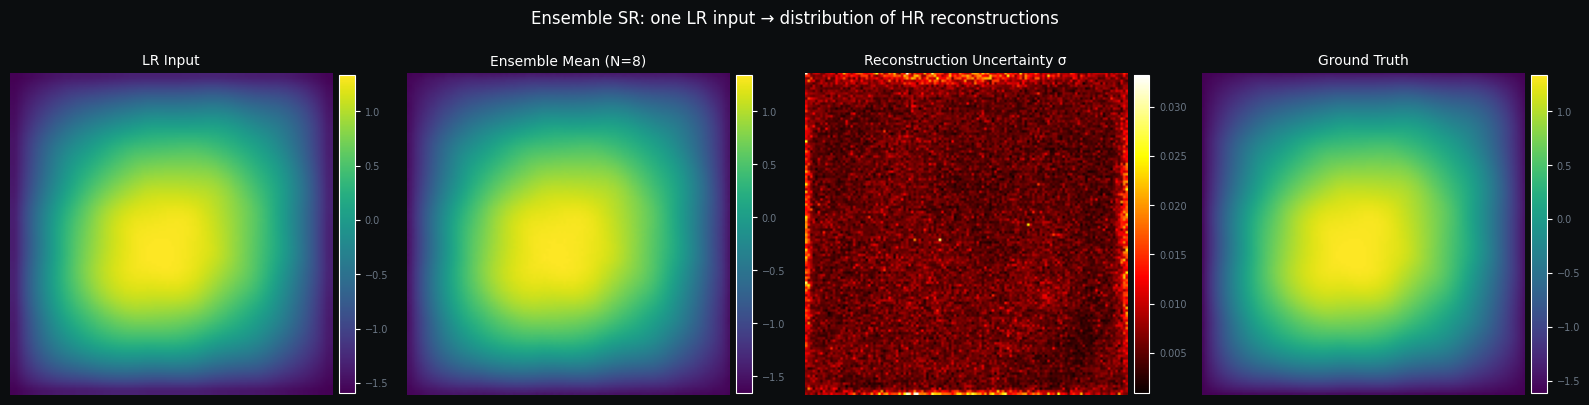

In [12]:
N_ENS = 8
lr_rep = lr_test[:1].expand(N_ENS, -1, -1, -1)

with torch.no_grad():
    ens = super_resolve(lr_rep, num_steps=40)   # (N, 1, H, W)

mean_sr = ens.mean(0, keepdim=True)
std_sr  = ens.std(0,  keepdim=True)
gt_s    = hr_test[:1]

print(f'Ensemble mean L2:      {rel_l2(mean_sr, gt_s).item():.4f}')
print(f'Reconstruction std:    {std_sr.mean().item():.6f}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('#0b0d0f')
for ax, d, title, cmap in zip(axes,
    [lr_test[0,0].cpu(), mean_sr[0,0].cpu(), std_sr[0,0].cpu(), gt_s[0,0].cpu()],
    ['LR Input', f'Ensemble Mean (N={N_ENS})', 'Reconstruction Uncertainty σ', 'Ground Truth'],
    ['viridis','viridis','hot','viridis']):
    ax.set_facecolor('#0b0d0f'); ax.axis('off')
    im = ax.imshow(d.numpy(), cmap=cmap, origin='lower')
    ax.set_title(title, color='white', fontsize=10, pad=6)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#6b7785', fontsize=7)
plt.suptitle('Ensemble SR: one LR input → distribution of HR reconstructions', color='white', y=1.02)
plt.tight_layout()
plt.savefig('ensemble_sr.png', dpi=180, bbox_inches='tight', facecolor='#0b0d0f')
plt.show()

## 9. Summary

In [13]:
bic_err  = rel_l2(hr_bicubic, hr_test).item()
diff_err = rel_l2(hr_sr, hr_test).item()

print('=' * 60)
print('  RESULTS SUMMARY')
print('=' * 60)
print(f'  PhysicsNeMo version:  {physicsnemo.__version__}')
print(f'  Task:                 Darcy flow SR  ({LR_RES}x{LR_RES} → {HR}x{HR})')
print(f'  Backbone:             Custom FNO  (physicsnemo.core.Module subclass)')
print(f'  Parameters:           {n_params:,}')
print(f'  Training steps:       {TRAIN_STEPS}')
print()
print(f'  PhysicsNeMo components used:')
print(f'    EDMLoss             (denoising score-matching)')
print(f'    EDMPreconditioner   (c_skip / c_out / c_in rescaling)')
print(f'    EDMNoiseScheduler   (Karras schedule + get_denoiser)')
print(f'    sample()            (Heun ODE sampler)')
print()
print(f'  Bicubic L2 error:     {bic_err:.4f}')
print(f'  Diffusion L2 error:   {diff_err:.4f}')
print(f'  Improvement:          {(bic_err-diff_err)/bic_err*100:.1f}% lower error')
print()
print(f'  Ensemble size:        {N_ENS}')
print(f'  Ensemble mean L2:     {rel_l2(mean_sr, gt_s).item():.4f}')
print(f'  Reconstruction std:   {std_sr.mean().item():.6f}')
print('=' * 60)

  RESULTS SUMMARY
  PhysicsNeMo version:  2.1.1
  Task:                 Darcy flow SR  (32x32 → 128x128)
  Backbone:             Custom FNO  (physicsnemo.core.Module subclass)
  Parameters:           4,312,705
  Training steps:       3000

  PhysicsNeMo components used:
    EDMLoss             (denoising score-matching)
    EDMPreconditioner   (c_skip / c_out / c_in rescaling)
    EDMNoiseScheduler   (Karras schedule + get_denoiser)
    sample()            (Heun ODE sampler)

  Bicubic L2 error:     0.0215
  Diffusion L2 error:   0.0111
  Improvement:          48.4% lower error

  Ensemble size:        8
  Ensemble mean L2:     0.0083
  Reconstruction std:   0.006086
